In [1]:
import numpy as np
import pandas as pd
from pandas import Series, DataFrame

df = pd.read_csv('../../data/train.csv')
df

,id,LoanNr_ChkDgt,Name,City,State,Bank,BankState,ApprovalDate,ApprovalFY,NoEmp,...,CreateJob,RetainedJob,FranchiseCode,UrbanRural,RevLineCr,LowDoc,DisbursementDate,DisbursementGross,BalanceGross,Accept
0,64afe857c28,9448323000,MIDWEST CRANKSHAFT & ENGINE,HARVEY,IL,JPMORGAN CHASE BANK NATL ASSOC,IL,9-Aug-96,1996,28,...,0,0,1,0,N,N,31-Mar-97,"$600,000.00",$0.00,0
1,1705a7346c2,2854405007,"Iredesign, Limited",CHICAGO,IL,JPMORGAN CHASE BANK NATL ASSOC,IL,10-Dec-07,2008,1,...,1,1,0,1,N,N,31-Dec-07,"$25,400.00",$0.00,1
2,7439801ad8a,9300423010,PHILLY'S INC.,ROCHELLE,IL,BMO HARRIS BK NATL ASSOC,IL,23-May-96,1996,6,...,0,0,1,0,N,Y,30-Sep-96,"$20,000.00",$0.00,1
3,a3f8f9d0611,4349265000,USA Laser Imaging Inc.,Loves park,IL,ALPINE BANK & TRUST CO.,IL,4-Nov-10,2011,5,...,0,5,0,1,N,N,1-Mar-11,"$75,000.00",$0.00,1
4,71e4f243b5d,2433905006,"Dan Morrell, Inc.",LISLE,IL,JPMORGAN CHASE BANK NATL ASSOC,IL,3-May-07,2007,3,...,1,3,0,1,N,N,31-May-07,"$50,000.00",$0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20763,530b1abc4d5,5400325006,OMC Construction & Restoration,MORTON GROVE,IL,JPMORGAN CHASE BANK NATL ASSOC,IL,7-Sep-12,2012,1,...,10,0,0,1,Y,N,7-Sep-12,"$45,000.00",$0.00,1
20764,d759e7e1aac,2242345001,Ronald J Wirth,ROMEOVILLE,IL,JPMORGAN CHASE BANK NATL ASSOC,IL,26-Jan-07,2007,1,...,6,4,0,1,N,N,31-Jan-07,"$55,000.00",$0.00,1
20765,d902be78167,7805983010,CHICAGO GOURMET FOODS,ELMHURST,IL,FIFTH THIRD BANK,IL,16-Nov-94,1995,8,...,0,0,1,0,N,Y,31-Jan-95,"$100,000.00",$0.00,0
20766,76adcc08afc,8905864007,"ANNIE RIVER SOLUTIONS, INC",GLEN ELLYN,IL,U.S. BANK NATIONAL ASSOCIATION,OH,6-Jun-05,2005,1,...,1,2,1,1,Y,N,30-Jun-05,"$178,634.00",$0.00,1


Query: What is the ratio of Approved vs. Denied loans?
<br>If 90% are accepted, the bank is aggressive. If 50% are denied, the bank is very conservative

        count  ratio_%
Accept                
1       16019    77.13
0        4749    22.87


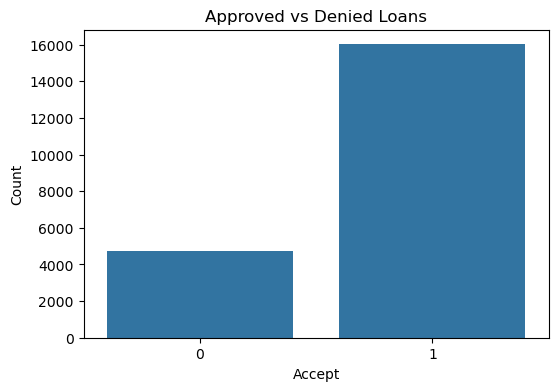

In [ ]:
# What is the ratio of Approved vs. Denied loans?
import seaborn as sns
import matplotlib.pyplot as plt

counts = df['Accept'].value_counts(dropna=False)
ratios = df['Accept'].value_counts(normalize=True, dropna=False).mul(100).round(2)

summary = pd.DataFrame({'count': counts, 'ratio_%': ratios})
print(summary)

plt.figure(figsize=(6, 4))
sns.countplot(x='Accept', data=df)
plt.title('Approved vs Denied Loans')
plt.xlabel('Accept')
plt.ylabel('Count')
plt.show()

How does business maturity (NewExist) affect the outcome?
<br>Does being a "New Business" double the risk of denial? If so, Company X needs a higher score elsewhere to balance
     it out.

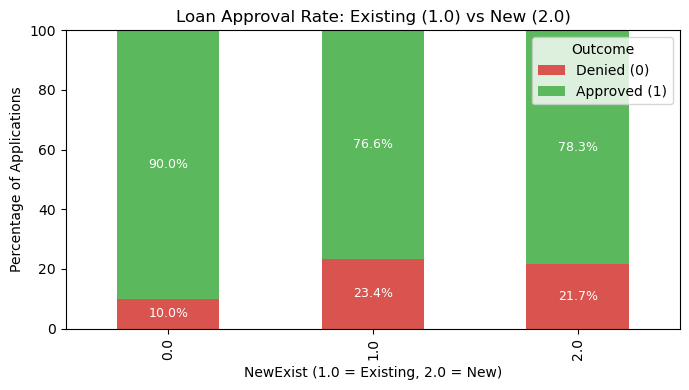

Accept,0,1
NewExist,,
0.0,10.000000,90.000000
1.0,23.416561,76.583439
2.0,21.712027,78.287973


In [3]:
# How does business maturity (NewExist) affect the outcome?
maturity_risk = (
    pd.crosstab(df['NewExist'], df['Accept'], normalize='index')
    .reindex(columns=[0, 1], fill_value=0)
    * 100
)

ax = maturity_risk.plot(
    kind='bar',
    stacked=True,
    color=['#d9534f', '#5cb85c'],
    figsize=(7, 4)
 )
ax.set_title('Loan Approval Rate: Existing (1.0) vs New (2.0)')
ax.set_xlabel('NewExist (1.0 = Existing, 2.0 = New)')
ax.set_ylabel('Percentage of Applications')
ax.set_ylim(0, 100)
ax.legend(['Denied (0)', 'Approved (1)'], title='Outcome', loc='upper right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', color='white', fontsize=9)

plt.tight_layout()
plt.show()

maturity_risk

In [4]:
# Quick check: what is NewExist = 0.0?
print('NewExist value counts:')
print(df['NewExist'].value_counts(dropna=False).sort_index())

print('\nNewExist vs Accept crosstab:')
display(pd.crosstab(df['NewExist'], df['Accept']))

NewExist value counts:
NewExist
0.0       10
1.0    14178
2.0     6577
NaN        3
Name: count, dtype: int64

NewExist vs Accept crosstab:


Accept,0,1
NewExist,,
0.0,1,9
1.0,3320,10858
2.0,1428,5149
